# Imports

In [1]:
import sys
sys.path.insert(0, '.')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
from IPython.display import Image
import datetime

from src.constants import *
from src.ingest import download_price_data_by_year, load_price_data, prices_by_day, get_sample_day
from src.optimize import build_and_solve
from src.simulate import run_simulation
from src.visualize import plot_price_profile, plot_dispatch_and_soc, plot_sensitivity, plot_profit_distribution
from src.sensitivity import annual, annualized_profit, to_df

# Data Download

In [2]:
OUTPUT_PATH = Path.cwd() / "data" / "sample_pjm_lmp.csv"

years = [2022, 2023]
frames = [download_price_data_by_year(y) for y in years]
combined = pd.concat(frames, ignore_index=True)
combined.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(combined):,} rows to {OUTPUT_PATH}")

Saved 16,320 rows to /home/roberto/Documents/portfolio_projects/EnergyMarket/BatteryOptimization/data/sample_pjm_lmp.csv


# Data Loading

In [3]:
# Load prices from the bundled sample CSV (2022-2023 PJM APS zone)
prices_df = load_price_data('data/sample_pjm_lmp.csv')
days = prices_by_day(prices_df)

print(f"Price data: {len(prices_df):,} hourly observations")
print(f"Tradeable days: {len(days)}")
print(f"Date range: {prices_df.index.min()} → {prices_df.index.max()}")
print(f"Price range: ${prices_df['lmp_usd_mwh'].min():.2f} – ${prices_df['lmp_usd_mwh'].max():.2f}/MWh")

prices_df.describe().round(2)

Price data: 16,320 hourly observations
Tradeable days: 680
Date range: 2022-01-01 01:00:00-05:00 → 2024-01-01 00:00:00-05:00
Price range: $10.01 – $480.88/MWh


,lmp_usd_mwh
count,16320.00
mean,55.03
std,36.77
min,10.01
25%,30.64
50%,45.14
75%,67.86
max,480.88


# Single-Day Optimization

Choosing 75th percentile to find representative day:
* 50th percentile (median):  Typical day. Price spreads may be modest, so the battery doesn't do much.
* 75th percentile: Moderately volatile day. There are enough price differences to show meaningful charging and discharging without being an extreme outlier.
* 90th–100th percentile: Very volatile days. Not representative of normal operation.

In [4]:
sample_date, sample_prices = get_sample_day(days, percentile=75)
sample_date, sample_prices

(datetime.date(2022, 7, 16),
 array([ 62.0175205,  58.771953 ,  55.844675 ,  51.7230385,  47.107183 ,
         44.9569955,  44.769217 ,  45.25588  ,  46.641066 ,  53.111978 ,
         60.9332885,  73.6494695,  82.9494395,  91.7025975,  91.9898715,
         95.9788005, 100.5417675, 107.98922  , 112.576583 , 105.9806345,
         98.3152035,  92.5756015,  90.6762355,  78.0756275]))

In [5]:
prices_df.loc["2022-07-16"]

,lmp_usd_mwh
datetime_et,
2022-07-16 00:00:00-04:00,62.017521
2022-07-16 01:00:00-04:00,58.771953
2022-07-16 02:00:00-04:00,55.844675
2022-07-16 03:00:00-04:00,51.723039
2022-07-16 04:00:00-04:00,47.107183
2022-07-16 05:00:00-04:00,44.956996
2022-07-16 06:00:00-04:00,44.769217
2022-07-16 07:00:00-04:00,45.255880
2022-07-16 08:00:00-04:00,46.641066


In [6]:
days[datetime.date(2022, 7, 16)]

array([ 62.0175205,  58.771953 ,  55.844675 ,  51.7230385,  47.107183 ,
        44.9569955,  44.769217 ,  45.25588  ,  46.641066 ,  53.111978 ,
        60.9332885,  73.6494695,  82.9494395,  91.7025975,  91.9898715,
        95.9788005, 100.5417675, 107.98922  , 112.576583 , 105.9806345,
        98.3152035,  92.5756015,  90.6762355,  78.0756275])

Saved: outputs/figures/price_profile.png


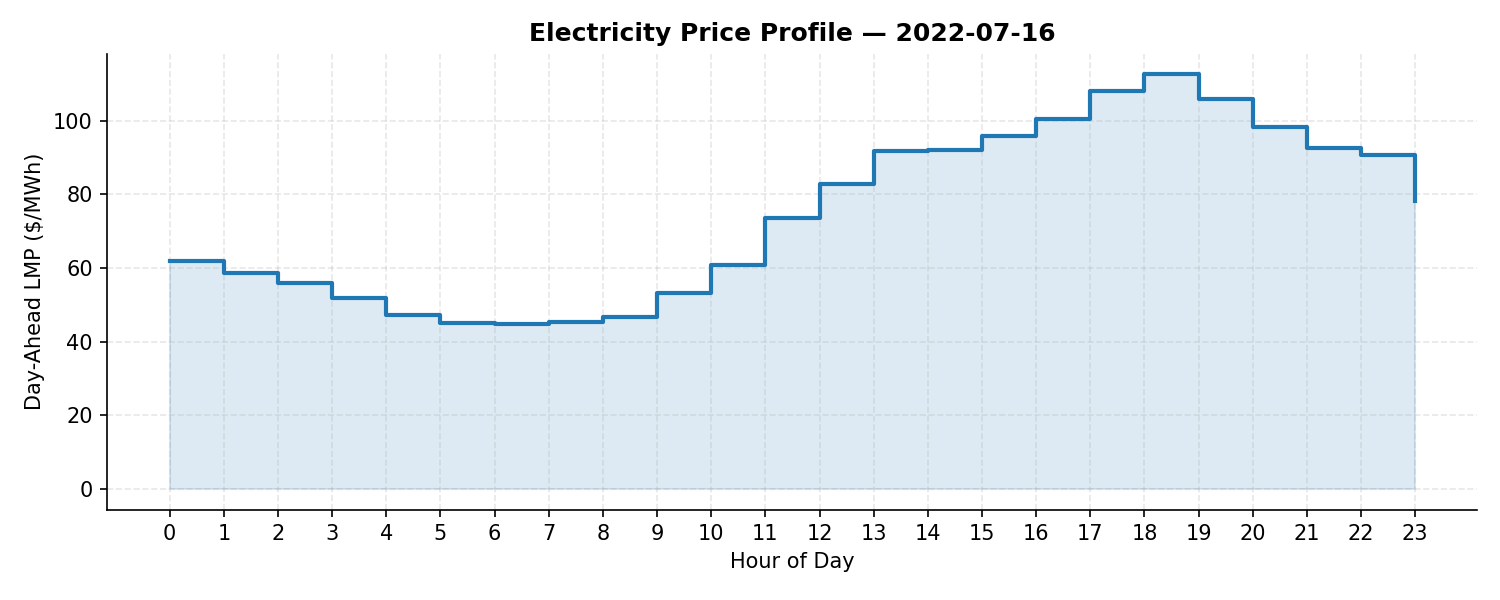

In [7]:
plot_price_profile(sample_prices, sample_date, 'outputs/figures/price_profile.png')
Image('outputs/figures/price_profile.png')

In [8]:
# optimization
result = build_and_solve(sample_prices)
result

{'charge_mw': array([  0.        ,   0.        ,   0.        ,  -0.        ,
         21.63702136, 100.        , 100.        , 100.        ,
        100.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ]),
 'discharge_mw': array([100.        ,  89.73665961,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,  -0.        ,  -0.        ,  -0.        ,
         -0.        ,  -0.        ,  -0.        ,  -0.        ,
         79.47331922, 100.        , 100.        , 100.        ,
         -0.        ,  -0.        ,  -0.        ,  -0.        ]),
 'soc_mwh': array([ 94.59074466,   0.        ,  -0.        ,   0.        ,
         20.52668078, 115.39501058, 210.26334039, 305.13167019,
        400.        , 400.        , 400.        , 400.      

In [9]:
# quick verification
result['soc_mwh'][0] + result['discharge_mw'][0]/0.9**0.5

np.float64(200.0)

In [10]:
print(f"Date   : {sample_date}")
print(f"Status : {result['status']}")
print(f"Profit : ${result['profit_usd']:,.0f}")
print(f"Energy charged    : {result['charge_mw'].sum():.1f} MWh")
print(f"Energy discharged : {result['discharge_mw'].sum():.1f} MWh")

Date   : 2022-07-16
Status : optimal
Profit : $32,939
Energy charged    : 421.6 MWh
Energy discharged : 569.2 MWh


In [11]:
# quick verification
# discharge = charge * RTE + initial_SOC * RTE^0.5
result['charge_mw'].sum() * 0.9 + 200 * 0.9**0.5

np.float64(569.2099788303084)

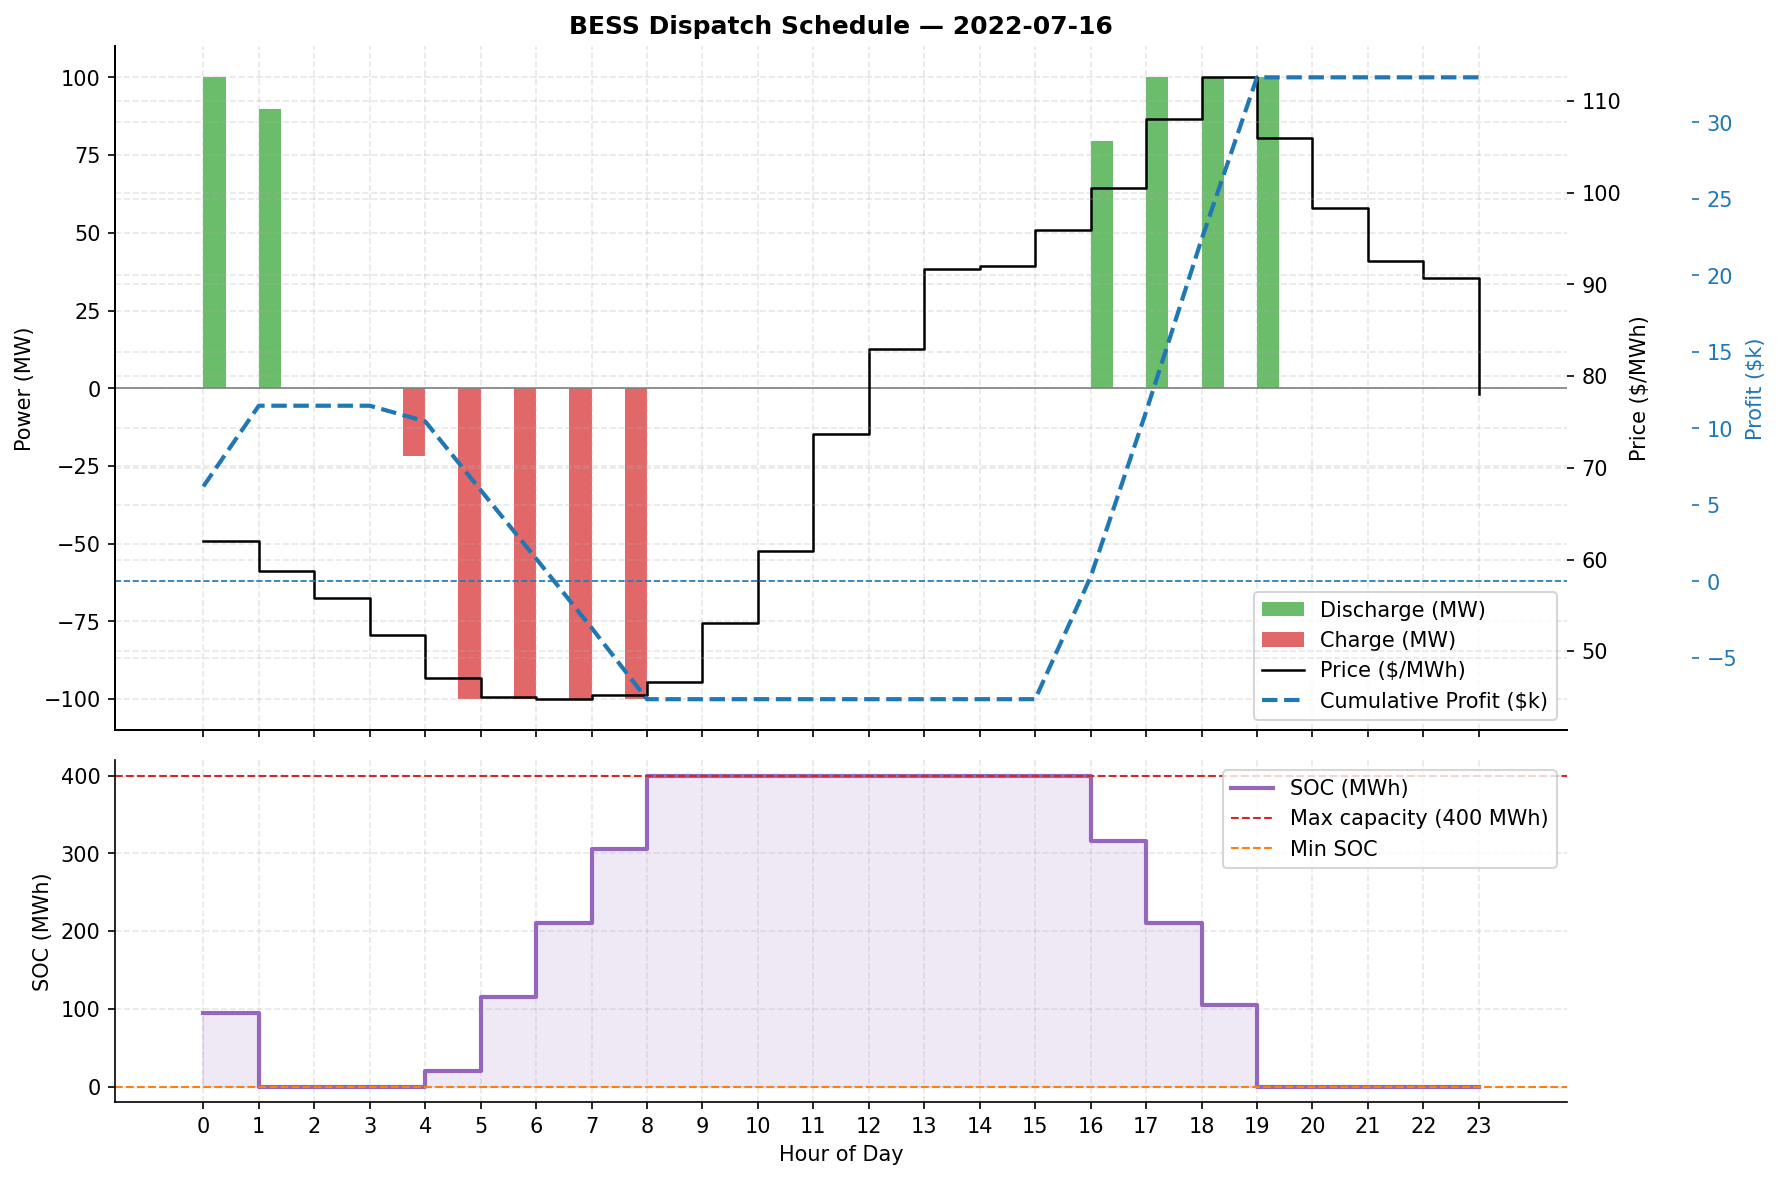

In [12]:
plot_dispatch_and_soc(
    sample_prices, result['charge_mw'], result['discharge_mw'], result['soc_mwh'],
    400.0, sample_date, 'outputs/figures/dispatch_schedule.png')
Image('outputs/figures/dispatch_schedule.png')

# Full Simulation

In [13]:
results = run_simulation(days)
results.head(10).round(0)

,profit_usd,charge_mwh,discharge_mwh,cycles,status
date,,,,,
2022-01-01,7088.0,322.0,479.0,1.0,optimal
2022-01-02,10697.0,211.0,379.0,1.0,optimal
2022-01-03,17309.0,611.0,739.0,2.0,optimal
2022-01-04,20943.0,632.0,759.0,2.0,optimal
2022-01-05,14630.0,422.0,570.0,1.0,optimal
2022-01-06,18308.0,511.0,649.0,1.0,optimal
2022-01-07,36988.0,544.0,679.0,1.0,optimal
2022-01-08,19167.0,522.0,659.0,1.0,optimal
2022-01-09,10604.0,333.0,490.0,1.0,optimal


In [14]:
print(f"Days simulated    : {len(results)}")
print(f"Total profit      : ${results['profit_usd'].sum():,.0f}")
print(f"Mean daily profit : ${results['profit_usd'].mean():,.0f}")
print(f"Max daily profit  : ${results['profit_usd'].max():,.0f}")
print(f"Annualized profit : ${results['profit_usd'].mean() * 365:,.0f}/year")

Days simulated    : 680
Total profit      : $16,652,981
Mean daily profit : $24,490
Max daily profit  : $151,163
Annualized profit : $8,938,732/year


Saved: outputs/figures/profit_distribution.png


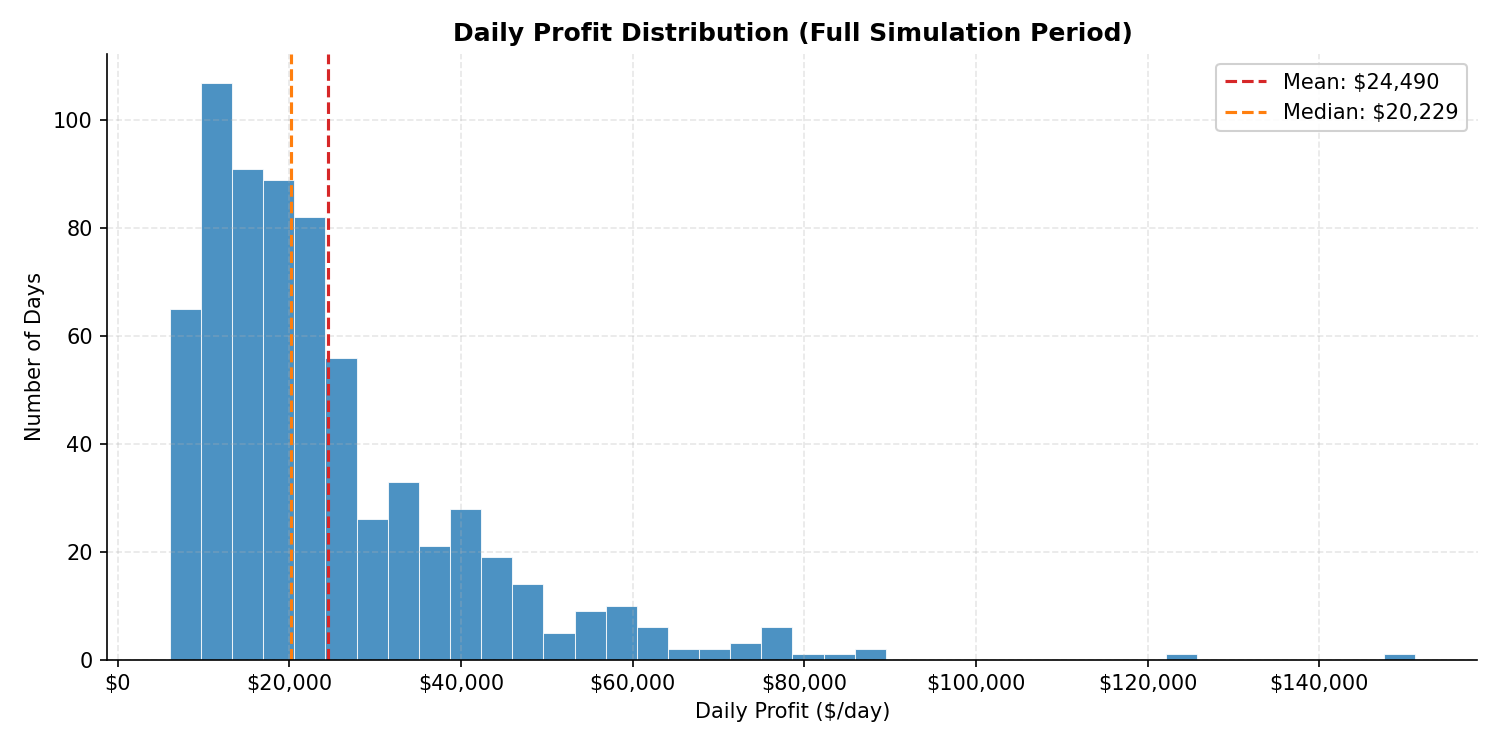

In [15]:
plot_profit_distribution(results, 'outputs/figures/profit_distribution.png')
Image('outputs/figures/profit_distribution.png')

# Sensitivity Analysis

In [16]:
# Parameter sweep ranges
RTE_VALUES = [0.75, 0.80, 0.85, 0.90, 0.95]
CAPACITY_VALUES = [200, 300, 400, 500, 600]  # MWh
POWER_VALUES = [50, 75, 100, 125, 150]  # MW

In [17]:
rte_results = {
    v: annual(days, rte=v, capacity_mwh=CAPACITY_MWH, power_mw=POWER_MW)
    for v in RTE_VALUES
}

In [18]:
cap_results = {
    v: annual(days, rte=RTE, capacity_mwh=v, power_mw=POWER_MW, soc_init_frac=0.50)
    for v in CAPACITY_VALUES
}

In [19]:
pwr_results = {
    v: annual(days, rte=RTE, capacity_mwh=CAPACITY_MWH, power_mw=v)
    for v in POWER_VALUES
}

In [20]:
sensitivity_res = {
    "rte": to_df(rte_results),
    "capacity": to_df(cap_results),
    "power": to_df(pwr_results),
}

Saved: outputs/figures/sensitivity.png


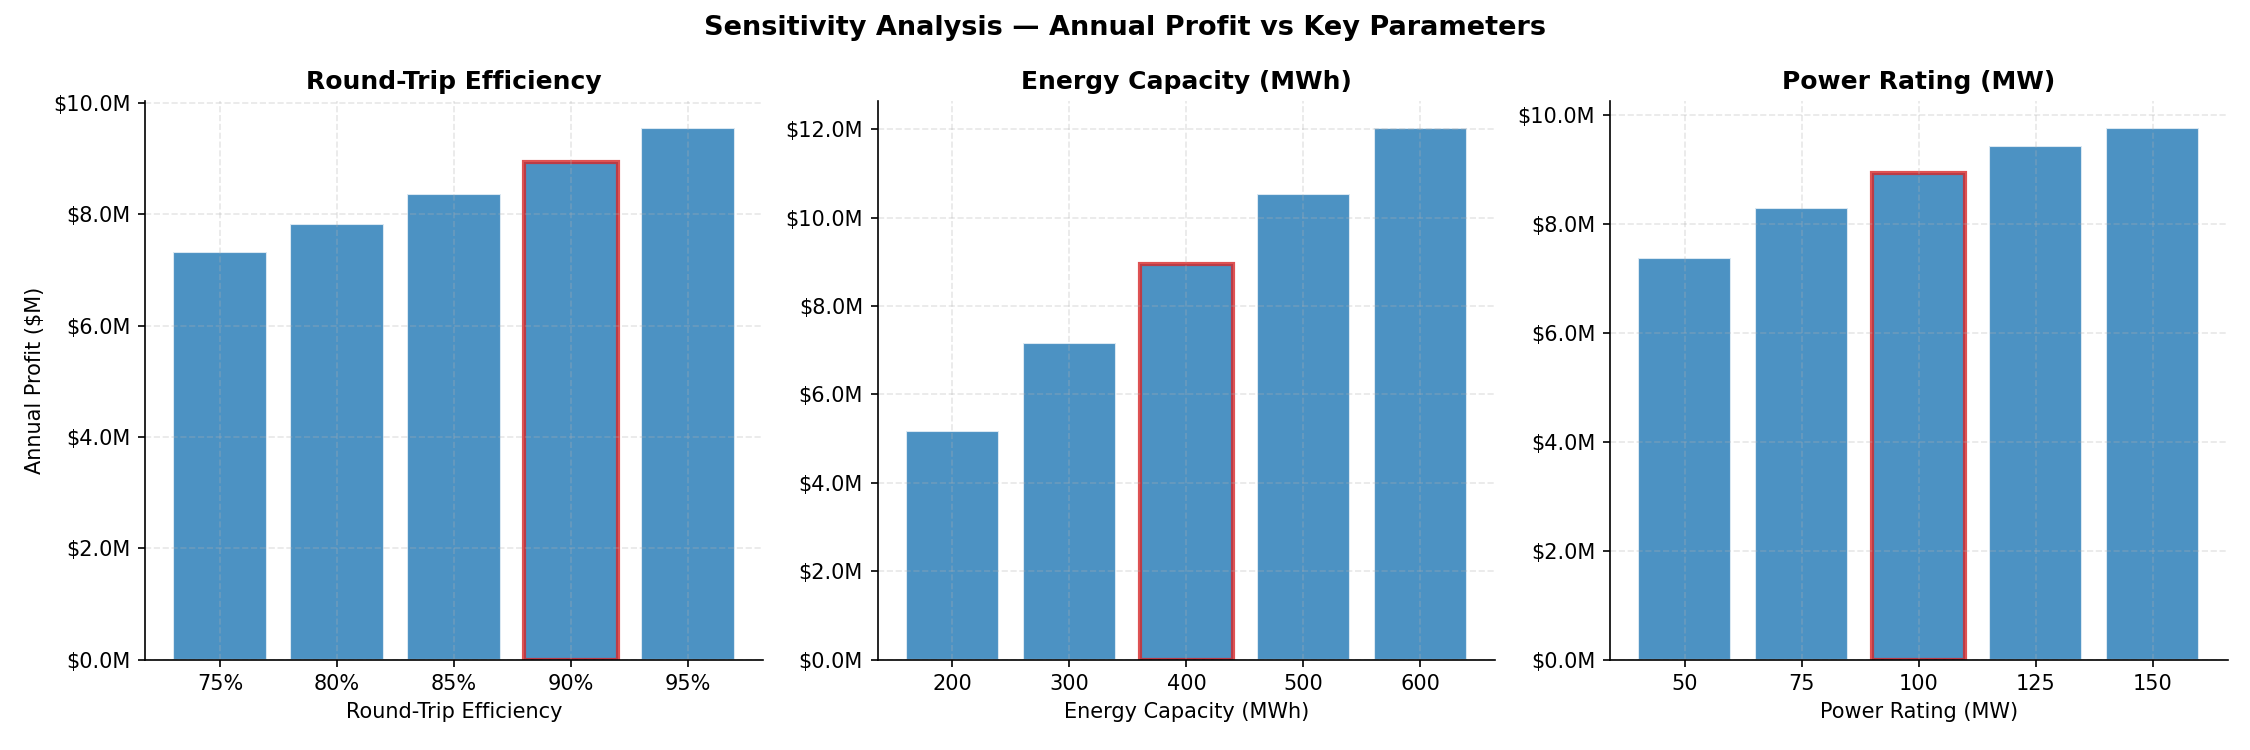

In [21]:
plot_sensitivity(sensitivity_res, 'outputs/figures/sensitivity.png')
Image('outputs/figures/sensitivity.png')

This plots are kind of useless, as profit monotonically increases with all these variables.
It would be more interesting if there were competing effects.
For example, as the battery capacity increases (both energy capacity and power ratings), the initial/maintenance cost will probably increase as well, which would reduce the profits.
In that case it would be possible to find the optimum energy capacity/power rating.

Let's quantify to which variable Annual Profit is most sensitive.

Sensitivity = profit change / parameter change

In [22]:
# Calculates sensitivity around the baseline values
base = {
    "rte": RTE,
    "capacity": CAPACITY_MWH,
    "power": POWER_MW,
}

for name, df_s in sensitivity_res.items():
    # Parameter values are the DataFrame index
    x = df_s.index.to_numpy(dtype=float)
    y = df_s["annual_profit_usd"].to_numpy()

    base_val = base[name]
    i = np.where(x == base_val)[0][0]

    # Use the points immediately below and above the baseline
    x0, x1 = x[i-1], x[i+1]
    y0, y1 = y[i-1], y[i+1]

    pct_param = (x1 - x0) / base_val
    pct_profit = (y1 - y0) / y[i]

    elasticity = pct_profit / pct_param
    print(f"{name.upper()}, Local elasticity at {base_val}: {elasticity:.2f}")

RTE, Local elasticity at 0.9: 1.20
CAPACITY, Local elasticity at 400.0: 0.76
POWER, Local elasticity at 100.0: 0.25


# Conclusions

The results show that profit is most sensitive to RTE.